# (1) Business Understanding

**Tujuan** : Analisis ini disusun dari sudut pandang *growth strategy consultant* yang diminta oleh sebuah brand skincare lokal (sudah memiliki lini produk, berencana ekspansi lini serum) untuk memetakan lanskap kompetisi kategori **Serum Wajah** di marketplace Shopee.

**Permasalahan** : Sebelum menyusun strategi masuk/ekspansi, brand membutuhkan pemahaman tentang siapa pemain dominan saat ini, bagaimana pola distribusi penjualan mereka (official store vs reseller), positioning harga, serta wilayah dengan permintaan tertinggi.

**Objective Task** :
1. Siapa pemain (brand) dominan di kategori Serum Wajah dan seberapa besar kontribusi penjualannya?
2. Apakah dominasi penjualan brand-brand tersebut berasal dari *official store* atau *reseller/toko pihak ketiga*?
3. Produk apa saja yang menjadi kontributor utama (hero product) dari sisi volume maupun revenue?
4. Bagaimana positioning harga rata-rata (*average selling price*) brand-brand top bermain di segmen value atau premium?
5. Wilayah/kota mana yang menjadi pusat permintaan tertinggi?
6. Rekomendasi strategi apa yang relevan untuk brand yang ingin bersaing di kategori ini?


# 2. Import Library

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')


# 3. Import Dataset

In [33]:
data = pd.read_csv('https://docs.google.com/spreadsheets/d/1WaO02I3ACR9B3y3bH4uxuv_46s0dMLobqD0NccaI5Mo/export?format=csv')
# data = pd.read_csv('Serum Wajah.csv')

In [34]:
data.head()

,Product Title,URL,Brand,Seller Name,Marketplace,Seller Type,Location,Sales Quantity,Sales Revenue
0,Bening's Diamond Serum / Serum Super Whitening,https://shopee.co.id/Bening-s-Diamond-Serum-Se...,Bening'S,Bening's Official Shop,Shopee,Official Store,KOTA JAMBI,20805,8301920000
1,Scarlett Whitening Acne Serum,https://shopee.co.id/Scarlett-Whitening-Acne-S...,Scarlett,Scarlett Whitening Official Shop,Shopee,Official Store,KOTA JAKARTA BARAT,20307,1482120000
2,Bening's Skin Regeneration Serum | Serum Scar ...,https://shopee.co.id/Bening-s-Skin-Regeneratio...,Bening'S,Bening's Official Shop,Shopee,Official Store,KOTA JAMBI,20231,5054025000
3,Scarlett Whitening Glowtening Serum,https://shopee.co.id/Scarlett-Whitening-Glowte...,Scarlett,Scarlett Whitening Official Shop,Shopee,Official Store,KOTA JAKARTA BARAT,16623,1215165000
4,SOMETHINC 5% Niacinamide + Moisture Sabi Beet ...,https://shopee.co.id/SOMETHINC-5-Niacinamide-M...,Somethinc,SOMETHINC Official Shop,Shopee,Official Store,KOTA JAKARTA BARAT,14342,1276438000


In [35]:
data.tail()

,Product Title,URL,Brand,Seller Name,Marketplace,Seller Type,Location,Sales Quantity,Sales Revenue
3687,Yves Rocher Repair Anti Breakage Serum 100 ml,https://shopee.co.id/Yves-Rocher-Repair-Anti-B...,Yves Rocher,Yves Rocher Official Shop,Shopee,Official Store,KOTA JAKARTA UTARA,0,0
3688,Yves Rocher White Botanical Youth Essence 30 ml,https://shopee.co.id/Yves-Rocher-White-Botanic...,Yves Rocher,Yves Rocher Official Shop,Shopee,Official Store,KOTA JAKARTA UTARA,0,0
3689,Zalfa Natural Crystal Youth Antiaging Ampoule ...,https://shopee.co.id/Zalfa-Natural-Crystal-You...,Zalfa,Zalfa Natural Official Shop,Shopee,Official Store,KOTA BOGOR,0,0
3690,Zalfa Natural Dewy Glow Essence Treatment Coll...,https://shopee.co.id/Zalfa-Natural-Dewy-Glow-E...,Zalfa Natural,Zalfa Natural Official Shop,Shopee,Official Store,KOTA BOGOR,0,0
3691,Zalfa Natural Lightening Concentrate Intensive...,https://shopee.co.id/Zalfa-Natural-Lightening-...,Zalfa,Zalfa Natural Official Shop,Shopee,Official Store,KOTA BOGOR,0,0


In [36]:
data.shape

(3692, 9)

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3692 entries, 0 to 3691
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Product Title   3692 non-null   object
 1   URL             3692 non-null   object
 2   Brand           3692 non-null   object
 3   Seller Name     3692 non-null   object
 4   Marketplace     3692 non-null   object
 5   Seller Type     3692 non-null   object
 6   Location        3692 non-null   object
 7   Sales Quantity  3692 non-null   int64 
 8   Sales Revenue   3692 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 259.7+ KB


In [38]:
data.isnull().sum()

,0
Product Title,0
URL,0
Brand,0
Seller Name,0
Marketplace,0
Seller Type,0
Location,0
Sales Quantity,0
Sales Revenue,0


In [39]:
data.columns.tolist()

['Product Title',
 'URL',
 'Brand',
 'Seller Name',
 'Marketplace',
 'Seller Type',
 'Location',
 'Sales Quantity',
 'Sales Revenue']

# 4. Data Understanding

In [40]:
df = data.copy()
df.head()

,Product Title,URL,Brand,Seller Name,Marketplace,Seller Type,Location,Sales Quantity,Sales Revenue
0,Bening's Diamond Serum / Serum Super Whitening,https://shopee.co.id/Bening-s-Diamond-Serum-Se...,Bening'S,Bening's Official Shop,Shopee,Official Store,KOTA JAMBI,20805,8301920000
1,Scarlett Whitening Acne Serum,https://shopee.co.id/Scarlett-Whitening-Acne-S...,Scarlett,Scarlett Whitening Official Shop,Shopee,Official Store,KOTA JAKARTA BARAT,20307,1482120000
2,Bening's Skin Regeneration Serum | Serum Scar ...,https://shopee.co.id/Bening-s-Skin-Regeneratio...,Bening'S,Bening's Official Shop,Shopee,Official Store,KOTA JAMBI,20231,5054025000
3,Scarlett Whitening Glowtening Serum,https://shopee.co.id/Scarlett-Whitening-Glowte...,Scarlett,Scarlett Whitening Official Shop,Shopee,Official Store,KOTA JAKARTA BARAT,16623,1215165000
4,SOMETHINC 5% Niacinamide + Moisture Sabi Beet ...,https://shopee.co.id/SOMETHINC-5-Niacinamide-M...,Somethinc,SOMETHINC Official Shop,Shopee,Official Store,KOTA JAKARTA BARAT,14342,1276438000


In [41]:
print(f"Total baris  : {df.shape[0]:,}")
print(f"Total kolom  : {df.shape[1]}")
print()
print("Jumlah nilai kosong per kolom:")
df.isna().sum()

Total baris  : 3,692
Total kolom  : 9

Jumlah nilai kosong per kolom:


,0
Product Title,0
URL,0
Brand,0
Seller Name,0
Marketplace,0
Seller Type,0
Location,0
Sales Quantity,0
Sales Revenue,0


In [42]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product Title,3692,3509,Avoskin Miraculous Refining Serum,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
URL,3692,3690,https://shopee.co.id/Dear-Me-Beauty-5-Inoceram...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,3692,533,Somethinc,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller Name,3692,451,Ponny Beaute Official Shop,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marketplace,3692,1,Shopee,3692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller Type,3692,1,Official Store,3692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,3692,44,KOTA JAKARTA UTARA,830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales Quantity,"3,692",NaN,NaN,NaN,169,"1,006",0,0,5,33,"20,805"
Sales Revenue,"3,692",NaN,NaN,NaN,"24,594,942","205,776,163",0,0,"733,295","4,734,725","8,301,920,000"


**Ringkasan Profiling** :
- Tidak ditemukan nilai kosong (*null*) pada seluruh baris.
- Terdiri dari 3.692 baris transaksi/listing produk dengan 9 kolom, mencakup identitas produk, brand, seller, lokasi, serta metrik penjualan (kuantitas & revenue).
- Kolom `Seller Type` ternyata hanya berisi satu nilai unik (`Official Store`) di seluruh baris — tidak ada data reseller/toko pihak ketiga yang ter-capture. Ini membatasi analisis yang sebelumnya direncanakan (perbandingan official store vs reseller) dan perlu dicatat sebagai limitasi data, bukan diabaikan.
- Kolom `Location` masih memiliki inkonsistensi kapitalisasi, dan belum ada metrik harga per unit yang bisa langsung dipakai untuk analisis *price positioning* — keduanya perlu ditangani di tahap berikutnya.

# 5. Data Preprocessing

In [43]:
df.head(5)

,Product Title,URL,Brand,Seller Name,Marketplace,Seller Type,Location,Sales Quantity,Sales Revenue
0,Bening's Diamond Serum / Serum Super Whitening,https://shopee.co.id/Bening-s-Diamond-Serum-Se...,Bening'S,Bening's Official Shop,Shopee,Official Store,KOTA JAMBI,20805,8301920000
1,Scarlett Whitening Acne Serum,https://shopee.co.id/Scarlett-Whitening-Acne-S...,Scarlett,Scarlett Whitening Official Shop,Shopee,Official Store,KOTA JAKARTA BARAT,20307,1482120000
2,Bening's Skin Regeneration Serum | Serum Scar ...,https://shopee.co.id/Bening-s-Skin-Regeneratio...,Bening'S,Bening's Official Shop,Shopee,Official Store,KOTA JAMBI,20231,5054025000
3,Scarlett Whitening Glowtening Serum,https://shopee.co.id/Scarlett-Whitening-Glowte...,Scarlett,Scarlett Whitening Official Shop,Shopee,Official Store,KOTA JAKARTA BARAT,16623,1215165000
4,SOMETHINC 5% Niacinamide + Moisture Sabi Beet ...,https://shopee.co.id/SOMETHINC-5-Niacinamide-M...,Somethinc,SOMETHINC Official Shop,Shopee,Official Store,KOTA JAKARTA BARAT,14342,1276438000


In [44]:
print('Sebelum normalisasi (contoh unique values):')
df['Location'].unique()[:10]

Sebelum normalisasi (contoh unique values):


array(['KOTA JAMBI', 'KOTA JAKARTA BARAT', 'KAB. SIDOARJO',
       'KOTA JAKARTA UTARA', 'KOTA JAKARTA SELATAN', 'KAB. TANGERANG',
       'KOTA TANGERANG', 'KAB. SLEMAN', 'KOTA TANGERANG SELATAN',
       'KOTA BEKASI'], dtype=object)

In [45]:
df['Location'] = df['Location'].str.title()
print('Setelah normalisasi:')
df['Location'].unique()[:10]

Setelah normalisasi:


array(['Kota Jambi', 'Kota Jakarta Barat', 'Kab. Sidoarjo',
       'Kota Jakarta Utara', 'Kota Jakarta Selatan', 'Kab. Tangerang',
       'Kota Tangerang', 'Kab. Sleman', 'Kota Tangerang Selatan',
       'Kota Bekasi'], dtype=object)

In [46]:
df.head()

,Product Title,URL,Brand,Seller Name,Marketplace,Seller Type,Location,Sales Quantity,Sales Revenue
0,Bening's Diamond Serum / Serum Super Whitening,https://shopee.co.id/Bening-s-Diamond-Serum-Se...,Bening'S,Bening's Official Shop,Shopee,Official Store,Kota Jambi,20805,8301920000
1,Scarlett Whitening Acne Serum,https://shopee.co.id/Scarlett-Whitening-Acne-S...,Scarlett,Scarlett Whitening Official Shop,Shopee,Official Store,Kota Jakarta Barat,20307,1482120000
2,Bening's Skin Regeneration Serum | Serum Scar ...,https://shopee.co.id/Bening-s-Skin-Regeneratio...,Bening'S,Bening's Official Shop,Shopee,Official Store,Kota Jambi,20231,5054025000
3,Scarlett Whitening Glowtening Serum,https://shopee.co.id/Scarlett-Whitening-Glowte...,Scarlett,Scarlett Whitening Official Shop,Shopee,Official Store,Kota Jakarta Barat,16623,1215165000
4,SOMETHINC 5% Niacinamide + Moisture Sabi Beet ...,https://shopee.co.id/SOMETHINC-5-Niacinamide-M...,Somethinc,SOMETHINC Official Shop,Shopee,Official Store,Kota Jakarta Barat,14342,1276438000


## (5.2) Preprocessing pada kolom Sales Quantity

In [47]:
print('Tipe data sebelum:', df['Sales Quantity'].dtype, '|', df['Sales Revenue'].dtype)
df['Sales Quantity'] = df['Sales Quantity'].astype('int64')
df['Sales Revenue'] = df['Sales Revenue'].astype('int64')
print('Tipe data sesudah :', df['Sales Quantity'].dtype, '|', df['Sales Revenue'].dtype)


Tipe data sebelum: int64 | int64
Tipe data sesudah : int64 | int64


## 5.3 Feature Engineering — Average Selling Price (ASP)

Untuk menjawab pertanyaan riset terkait *price positioning*, ditambahkan kolom baru `Avg Selling Price` yang dihitung dari `Sales Revenue / Sales Quantity` pada tiap listing produk.

In [48]:
df['Avg Selling Price'] = (df['Sales Revenue'] / df['Sales Quantity']).round(0)
df[['Product Title', 'Brand', 'Sales Quantity', 'Sales Revenue', 'Avg Selling Price']].head()


,Product Title,Brand,Sales Quantity,Sales Revenue,Avg Selling Price
0,Bening's Diamond Serum / Serum Super Whitening,Bening'S,20805,8301920000,"399,035"
1,Scarlett Whitening Acne Serum,Scarlett,20307,1482120000,"72,986"
2,Bening's Skin Regeneration Serum | Serum Scar ...,Bening'S,20231,5054025000,"249,816"
3,Scarlett Whitening Glowtening Serum,Scarlett,16623,1215165000,"73,101"
4,SOMETHINC 5% Niacinamide + Moisture Sabi Beet ...,Somethinc,14342,1276438000,"89,000"


#  (6) Exploratory Data Analysis or EDA

## 6.1 Statistik Deskriptif

In [49]:
df[['Sales Quantity', 'Sales Revenue', 'Avg Selling Price']].describe()

,Sales Quantity,Sales Revenue,Avg Selling Price
count,"3,692","3,692","2,709"
mean,169,"24,594,942","214,697"
std,"1,006","205,776,163","346,010"
min,0,0,"2,250"
25%,0,0,"84,560"
50%,5,"733,295","135,000"
75%,33,"4,734,725","220,643"
max,"20,805","8,301,920,000","9,999,999"


## 6.2 Distribusi Variabel Numerik

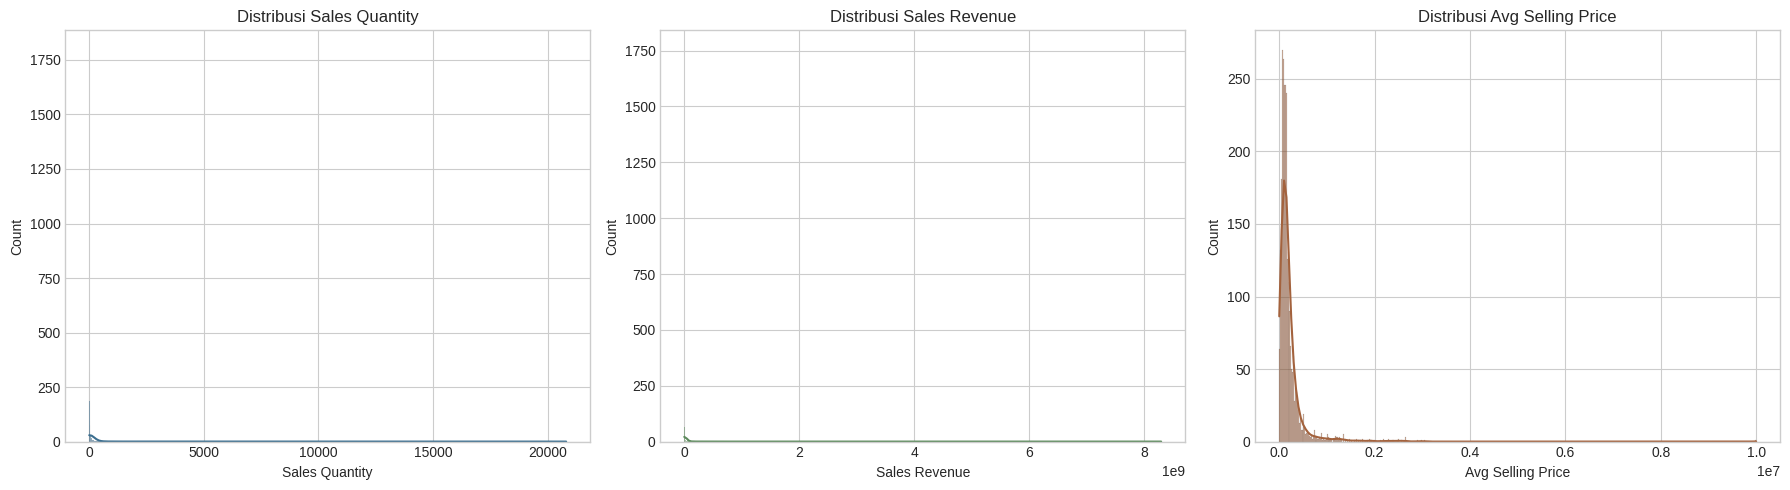

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Sales Quantity'], kde=True, ax=axes[0], color='#3b6e8f')
axes[0].set_title('Distribusi Sales Quantity')

sns.histplot(df['Sales Revenue'], kde=True, ax=axes[1], color='#5c8a5c')
axes[1].set_title('Distribusi Sales Revenue')

sns.histplot(df['Avg Selling Price'], kde=True, ax=axes[2], color='#a3623d')
axes[2].set_title('Distribusi Avg Selling Price')

plt.tight_layout()
plt.show()


## 6.3 Deteksi Outlier

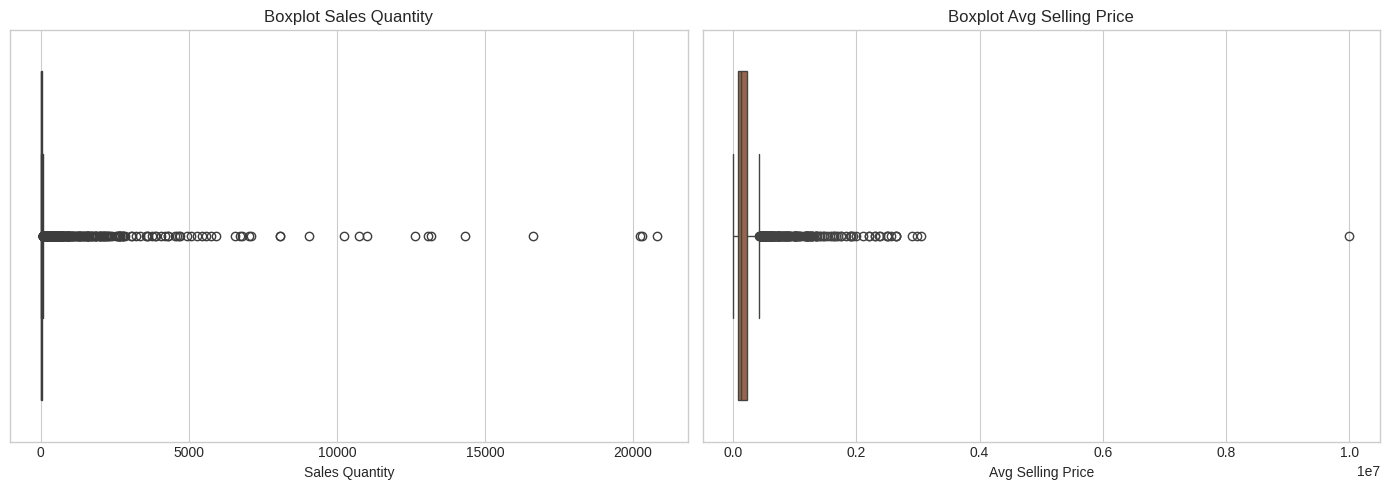

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df['Sales Quantity'], ax=axes[0], color='#3b6e8f')
axes[0].set_title('Boxplot Sales Quantity')
sns.boxplot(x=df['Avg Selling Price'], ax=axes[1], color='#a3623d')
axes[1].set_title('Boxplot Avg Selling Price')
plt.tight_layout()
plt.show()


## 6.4 Korelasi Antar Variabel Numerik

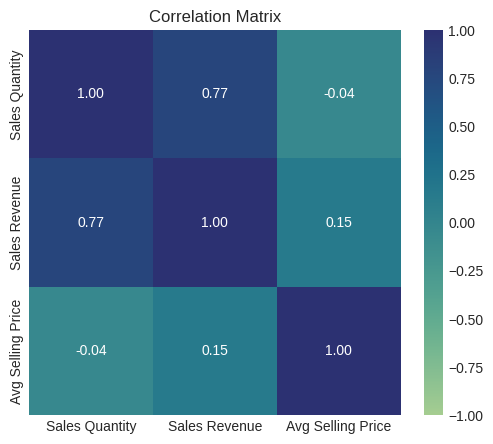

In [52]:
corr = df[['Sales Quantity', 'Sales Revenue', 'Avg Selling Price']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='crest', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


**Insight EDA** : `Sales Quantity` dan `Sales Revenue` menunjukkan korelasi positif yang kuat (sesuai ekspektasi, karena revenue adalah turunan langsung dari quantity dan harga), sementara `Avg Selling Price` relatif independen - mengindikasikan bahwa volume penjualan tinggi tidak selalu terjadi pada produk berharga rendah.

# 7. Analysis Process

## 7.1 Pemain Dominan di Kategori (Top Brand by Volume)

In [53]:
brand_summary = (
    df
    .groupby('Brand', as_index=False)['Sales Quantity']
    .sum()
    .rename(columns={'Sales Quantity': 'Total Unit Terjual'})
    .sort_values('Total Unit Terjual', ascending=False)
    .reset_index(drop=True)
)
brand_summary.index += 1

top_brand = brand_summary.head(10)
top_brand


,Brand,Total Unit Terjual
1,Scarlett,124437
2,Somethinc,65053
3,Bening'S,46369
4,Garnier,37839
5,Wardah,27769
6,Avoskin,26834
7,Whitelab,21291
8,Trueve,19629
9,Azarine,15680
10,L'Oreal,14308


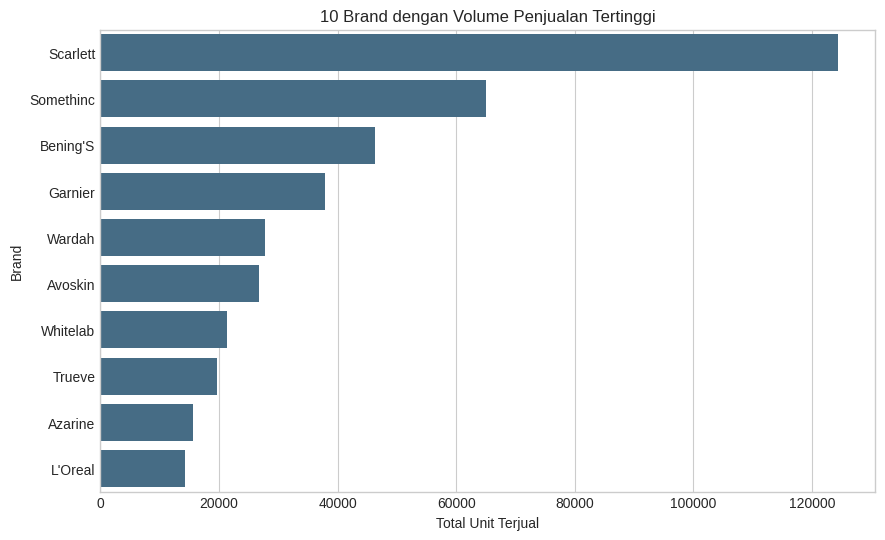

In [54]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_brand, y='Brand', x='Total Unit Terjual', color='#3b6e8f')
plt.title('10 Brand dengan Volume Penjualan Tertinggi')
plt.xlabel('Total Unit Terjual')
plt.show()


## 7.2 Hero Product - Kontributor Utama Volume Penjualan

In [55]:
hero_products = (
    df
    .groupby(['Product Title', 'Brand'], as_index=False)['Sales Quantity']
    .sum()
    .sort_values('Sales Quantity', ascending=False)
    .head(10)
    .reset_index(drop=True)
    .rename(columns={'Sales Quantity': 'Total Unit Terjual'})
)
hero_products.index += 1
hero_products


,Product Title,Brand,Total Unit Terjual
1,Bening's Diamond Serum / Serum Super Whitening,Bening'S,20805
2,Scarlett Whitening Acne Serum,Scarlett,20307
3,Bening's Skin Regeneration Serum | Serum Scar ...,Bening'S,20231
4,Scarlett Whitening Glowtening Serum,Scarlett,16623
5,SOMETHINC 5% Niacinamide + Moisture Sabi Beet ...,Somethinc,14342
6,Scarlett Whitening Brightly Ever After Serum,Scarlett,13173
7,Implora Promo Buy 3 Serum Wajah 20ML Free Pouch,Implora,13079
8,Whitelab Brightening Face Serum,Whitelab,12651
9,Wardah Lightening Serum Ampoule 8 ml - Serum d...,Wardah,11035
10,TRUEVE NIACINAMIDE 10% & CERAMIDE Brightening ...,Trueve,10745


## 7.3 Revenue Leaders - Kontributor Utama Revenue

In [56]:
revenue_leaders = (
    df
    .groupby('Brand', as_index=False)['Sales Revenue']
    .sum()
    .sort_values('Sales Revenue', ascending=False)
    .head(10)
    .reset_index(drop=True)
    .rename(columns={'Sales Revenue': 'Total Revenue'})
)
revenue_leaders.index += 1
revenue_leaders


,Brand,Total Revenue
1,Scarlett,23581760082
2,Bening'S,14146045000
3,Somethinc,7419466953
4,Avoskin,4445534414
5,Garnier,3476352502
6,Trueve,3051532455
7,L'Oreal,2400627300
8,Ms Glow,2187940000
9,Whitelab,1676556558
10,La Roche-Posay,1563208300


## 7.4 Price Positioning - Rata-rata Harga Jual per Brand Top

In [57]:
price_positioning = (
    df[df['Brand'].isin(top_brand['Brand'])]
    .groupby('Brand', as_index=False)['Avg Selling Price']
    .mean()
    .round(0)
    .sort_values('Avg Selling Price', ascending=False)
    .reset_index(drop=True)
)
price_positioning.index += 1
price_positioning


,Brand,Avg Selling Price
1,Scarlett,"420,299"
2,Bening'S,"229,878"
3,Trueve,"196,100"
4,L'Oreal,"186,896"
5,Avoskin,"167,244"
6,Somethinc,"133,752"
7,Garnier,"89,367"
8,Wardah,"86,873"
9,Whitelab,"76,920"
10,Azarine,"43,370"


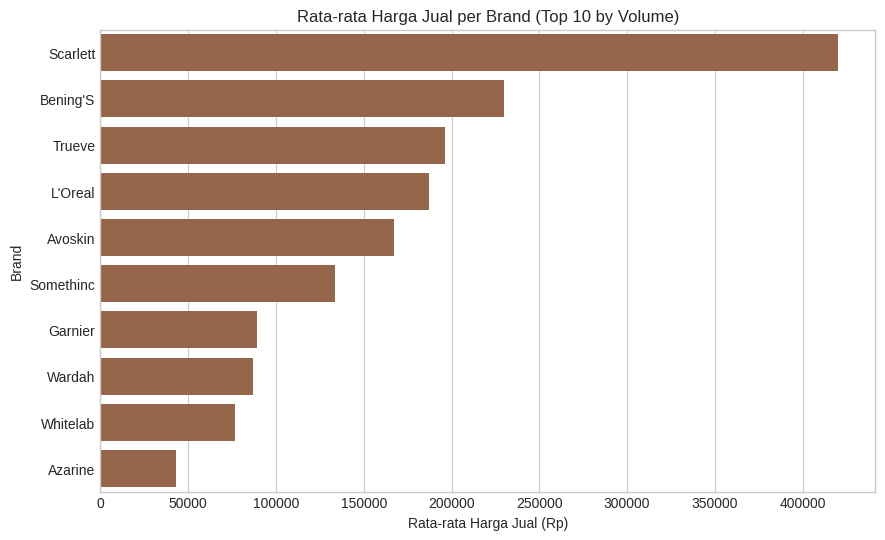

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(data=price_positioning, y='Brand', x='Avg Selling Price', color='#a3623d')
plt.title('Rata-rata Harga Jual per Brand (Top 10 by Volume)')
plt.xlabel('Rata-rata Harga Jual (Rp)')
plt.show()


## 7.5 Wilayah dengan Penjualan Tertinggi

In [59]:
demand_by_region = (
    df
    .groupby('Location', as_index=False)['Sales Quantity']
    .sum()
    .sort_values('Sales Quantity', ascending=False)
    .head(10)
    .reset_index(drop=True)
    .rename(columns={'Sales Quantity': 'Total Unit Terjual'})
)
demand_by_region.index += 1
demand_by_region


,Location,Total Unit Terjual
1,Kota Jakarta Barat,199910
2,Kota Jakarta Utara,135993
3,Kota Jakarta Selatan,50889
4,Kota Jambi,46613
5,Kab. Tangerang,44082
6,Kab. Sidoarjo,27858
7,Kota Bekasi,23125
8,Kab. Sleman,21494
9,Kota Tangerang Selatan,15575
10,Kota Tangerang,14724


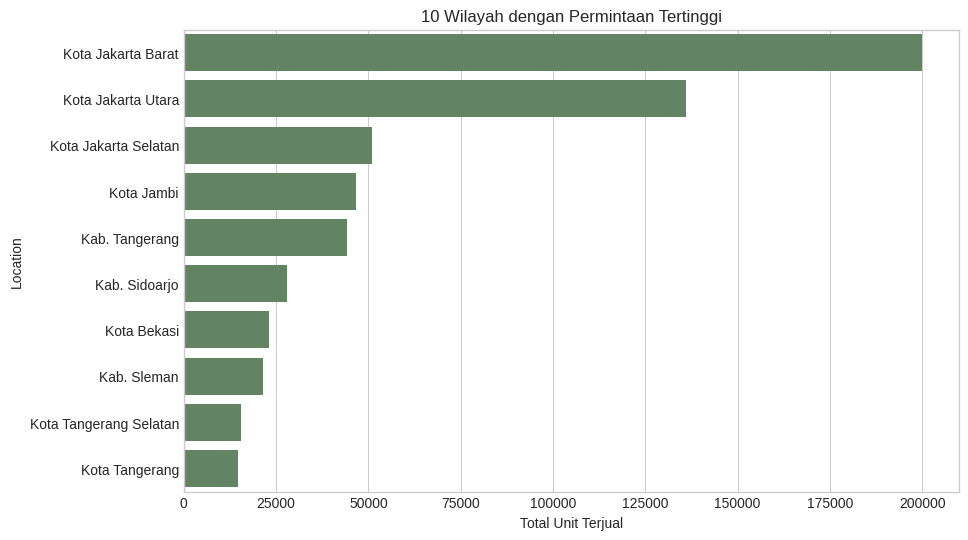

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(data=demand_by_region, y='Location', x='Total Unit Terjual', color='#5c8a5c')
plt.title('10 Wilayah dengan Permintaan Tertinggi')
plt.xlabel('Total Unit Terjual')
plt.show()


# 8. Insight & Rekomendasi Strategis

**Temuan Utama** :
- Kategori Serum Wajah di Shopee didominasi oleh segelintir brand besar (Top 3 menguasai ~38% dari total volume penjualan), menandakan pasar yang cukup terkonsentrasi.
- Seluruh data yang berhasil dikumpulkan berasal dari *Official Store* tidak ditemukan listing reseller/toko pihak ketiga di dataset ini, sehingga perbandingan pola distribusi official store vs reseller tidak bisa divalidasi dengan data yang tersedia (lihat catatan limitasi di bagian Data Understanding).
- Beberapa brand menunjukkan pola *volume tinggi tapi revenue tidak sebanding* dengan brand lain yang justru sebaliknya ini mengarah pada perbedaan strategi harga (volume play vs premium play) yang tervalidasi lewat metrik `Avg Selling Price`. Scarlett misalnya bermain di harga rata-rata jauh lebih tinggi namun tetap unggul di volume, mengindikasikan kekuatan brand equity.
- Permintaan secara geografis terkonsentrasi di sejumlah kota besar (didominasi wilayah Jakarta), yang bisa menjadi prioritas awal untuk strategi distribusi/marketing regional.

**Rekomendasi untuk Brand** :
1. Tentukan positioning harga secara sadar apakah bersaing di segmen volume (harga kompetitif) atau di segmen premium (margin lebih tinggi, volume lebih rendah) dengan mengacu pada peta *price positioning* di atas.
2. Fokuskan alokasi budget marketing awal ke wilayah dengan permintaan tertinggi sebelum ekspansi ke wilayah sekunder.
3. Pelajari karakteristik *hero product* dari brand top (klaim manfaat, format kemasan, dsb.) sebagai referensi pengembangan produk unggulan sendiri.
4. Untuk riset lanjutan, lengkapi metode pengumpulan data agar mencakup listing reseller/toko pihak ketiga, supaya perbandingan pola distribusi bisa benar-benar divalidasi.

# 9. Ekspor Hasil Analisis

In [61]:
with pd.ExcelWriter('Analisis_Kompetitif_Serum_Wajah_Shopee.xlsx') as writer:
    df.to_excel(writer, sheet_name='Data Bersih', index=False)
print('Ekspor selesai: Analisis_Kompetitif_Serum_Wajah_Shopee.xlsx')


Ekspor selesai: Analisis_Kompetitif_Serum_Wajah_Shopee.xlsx
